In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score, davies_bouldin_score, f1_score,
)
from xgboost import XGBRegressor

RANDOM_STATE = 42
N_CLUSTERS   = 3   # risk tiers: High / Medium / Low

# final_grade is a CONTINUOUS score (assumed 0-100) -> grade model is a REGRESSOR.
# Bands + pass/fail are derived from the predicted number for reporting only.
PASS_FAIL_BOUNDARY = 40.0
BAND_CUTS  = [40, 55, 70]
BAND_NAMES = ['Fail', 'Pass', 'Merit', 'Distinction']

def to_band(grades):
    """Map continuous grade(s) -> ordinal band index 0..3 via BAND_CUTS."""
    return np.digitize(grades, BAND_CUTS)

def add_cluster_onehot(X_scaled, clusters, n=N_CLUSTERS):
    """Append a one-hot of the risk cluster to the scaled feature matrix."""
    return np.hstack([X_scaled, np.eye(n)[np.asarray(clusters)]])

In [ ]:
df = pd.read_csv('academiq_v7.csv')
df = df.drop_duplicates().reset_index(drop=True)
df = df.drop(columns=['risk_cluster'], errors='ignore')   # all-zero placeholder; we refill it

# Drop rows with no grade label (can't train/evaluate on those)
n_before = len(df)
df = df.dropna(subset=['final_grade']).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows with missing final_grade ({len(df)} remain).")

# Keep a pristine copy (ORIGINAL feature values) for the saved dataset
df_raw = df.copy()

# --- Feature engineering (on the working copy only) ---
df['clicks_per_day'] = np.where(df['active_days'] > 0,
                                df['all_clicks'] / df['active_days'], 0)

LOG_COLS = ['all_clicks', 'material_clicks', 'total_time_spent', 'clicks_per_day']
for col in LOG_COLS:
    df[col] = np.log1p(df[col])

PROC_LOW, PROC_HIGH = df['procrastination_index'].quantile([0.01, 0.99])
df['procrastination_index'] = df['procrastination_index'].clip(PROC_LOW, PROC_HIGH)

# Behavioural features ONLY - no final_grade, no risk_cluster
FEATURE_COLS = [
    'all_clicks', 'active_days', 'access_frequency', 'material_clicks',
    'avg_quiz_score', 'quiz_attempts', 'avg_assignment_score',
    'assignment_submissions', 'total_time_spent', 'clicks_per_day',
    'procrastination_index', 'late_submission_count',
]

X         = df[FEATURE_COLS].values
y_numeric = df['final_grade'].values.astype(float)
y_band    = to_band(y_numeric)

print(f"\nFeature matrix: {X.shape}")
print(f"Grade: min={y_numeric.min():.1f}  max={y_numeric.max():.1f}  "
      f"mean={y_numeric.mean():.1f}  std={y_numeric.std():.1f}")
print("Band distribution:", {BAND_NAMES[i]: int((y_band == i).sum()) for i in range(4)})

Dropped 0 rows with missing final_grade (29473 remain).

Feature matrix: (29473, 12)
Grade: min=8.9  max=99.8  mean=54.2  std=19.0
Band distribution: {'Fail': 9543, 'Pass': 3747, 'Merit': 11151, 'Distinction': 5032}


In [ ]:
idx = np.arange(len(df))
(X_train, X_test, ynum_train, ynum_test,
 yband_train, yband_test, idx_train, idx_test) = train_test_split(
    X, y_numeric, y_band, idx, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_band,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (23578, 12), Test: (5895, 12)


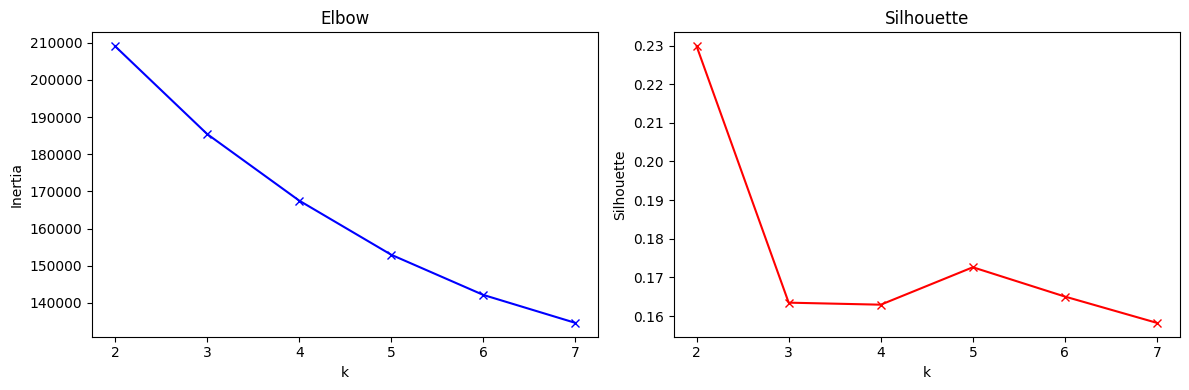

In [ ]:
#CELL 3 - KMeans diagnostics (elbow + silhouette)
inertia, silh = [], []
K_RANGE = range(2, 8)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertia.append(km.inertia_)
    silh.append(silhouette_score(X_train_scaled, labels))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(list(K_RANGE), inertia, 'bx-'); a1.set_xlabel('k'); a1.set_ylabel('Inertia'); a1.set_title('Elbow')
a2.plot(list(K_RANGE), silh, 'rx-'); a2.set_xlabel('k'); a2.set_ylabel('Silhouette'); a2.set_title('Silhouette')
plt.tight_layout(); plt.savefig('kmeans_elbow.png', dpi=120, bbox_inches='tight'); plt.show()

In [ ]:
# CELL 4 - KMeans clustering, risk mapping, cluster classifier, fill column
# 1) Discover clusters from BEHAVIOUR only (grade is NOT used here)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters  = kmeans.predict(X_test_scaled)

print(f"Silhouette (train):     {silhouette_score(X_train_scaled, train_clusters):.3f}")
print(f"Davies-Bouldin (train): {davies_bouldin_score(X_train_scaled, train_clusters):.3f}  (lower=better)")

# 2) Name clusters by mean grade (labelling only - lowest grade = highest risk)
cluster_grade = pd.DataFrame({'cluster': train_clusters, 'grade': ynum_train})
order = cluster_grade.groupby('cluster')['grade'].mean().sort_values().index.tolist()
RISK_MAP = {order[0]: 'High Risk', order[1]: 'Medium Risk', order[2]: 'Low Risk'}
print(f"\nCluster -> Risk mapping: {RISK_MAP}")
print(cluster_grade.groupby('cluster')['grade'].agg(['mean', 'count']))

# 3) Supervised classifier so NEW data can be assigned a cluster from features alone
rf_cluster = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
rf_cluster.fit(X_train_scaled, train_clusters)
print(f"\nCluster classifier accuracy (vs KMeans on test): "
      f"{accuracy_score(test_clusters, rf_cluster.predict(X_test_scaled)):.3f}")

# 4) FILL the risk_cluster column for EVERY row (exact KMeans assignment)
all_clusters = kmeans.predict(scaler.transform(X))
df['risk_cluster']     = all_clusters
df_raw['risk_cluster'] = all_clusters
print(f"\nFilled risk_cluster for all {len(df_raw)} rows: "
      f"{pd.Series(all_clusters).value_counts().sort_index().to_dict()}")

Silhouette (train):     0.163
Davies-Bouldin (train): 1.815  (lower=better)

Cluster -> Risk mapping: {1: 'High Risk', 2: 'Medium Risk', 0: 'Low Risk'}
              mean  count
cluster                  
0        67.953136   8145
1        38.213323   5180
2        51.472556  10253

Cluster classifier accuracy (vs KMeans on test): 0.949

Filled risk_cluster for all 29473 rows: {0: 10206, 1: 6456, 2: 12811}


In [ ]:
#CELL 5 - Train grade REGRESSOR on features + risk_cluster
X_train_aug = add_cluster_onehot(X_train_scaled, train_clusters)
X_test_aug  = add_cluster_onehot(X_test_scaled,  test_clusters)
print(f"Augmented feature matrix: {X_train_aug.shape}  "
      f"({len(FEATURE_COLS)} behavioural + {N_CLUSTERS} cluster one-hot)")

grade_reg = XGBRegressor(
    n_estimators=700, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=2.0,
    random_state=RANDOM_STATE, n_jobs=-1,
)
grade_reg.fit(X_train_aug, ynum_train)
print("Grade regressor trained (features + risk_cluster).")

Augmented feature matrix: (23578, 15)  (12 behavioural + 3 cluster one-hot)
Grade regressor trained (features + risk_cluster).


In [ ]:
#CELL 6 - Numeric grade metrics
y_pred_numeric = np.clip(grade_reg.predict(X_test_aug), 0, 100)

print("=" * 50)
print(" GRADE PREDICTION - NUMERIC METRICS")
print("=" * 50)
mae  = mean_absolute_error(ynum_test, y_pred_numeric)
rmse = np.sqrt(mean_squared_error(ynum_test, y_pred_numeric))
r2   = r2_score(ynum_test, y_pred_numeric)
baseline = mean_absolute_error(ynum_test, np.full_like(ynum_test, ynum_train.mean()))
print(f"MAE:  {mae:.2f} grade points  (mean-predictor baseline: {baseline:.2f})")
print(f"RMSE: {rmse:.2f}")
print(f"R^2:  {r2:.4f}")

pass_acc = ((y_pred_numeric >= PASS_FAIL_BOUNDARY) == (ynum_test >= PASS_FAIL_BOUNDARY)).mean()
print(f"\nPass/Fail accuracy (>= {PASS_FAIL_BOUNDARY}): {pass_acc:.3f}")

 GRADE PREDICTION - NUMERIC METRICS
MAE:  9.22 grade points  (mean-predictor baseline: 17.01)
RMSE: 11.91
R^2:  0.6062

Pass/Fail accuracy (>= 40.0): 0.819


In [ ]:
#CELL 7 - Band classification metrics
yband_pred = to_band(y_pred_numeric)
labels = range(len(BAND_NAMES))

print(f"Band macro F1:    {f1_score(yband_test, yband_pred, average='macro', zero_division=0):.4f}")
print(f"Band weighted F1: {f1_score(yband_test, yband_pred, average='weighted', zero_division=0):.4f}")
print("Per-band F1:")
for name, f in zip(BAND_NAMES,
                   f1_score(yband_test, yband_pred, average=None, labels=labels, zero_division=0)):
    print(f"  {name:12s}: {f:.3f}")

print("\nClassification report (bands):")
print(classification_report(yband_test, yband_pred, labels=labels,
                            target_names=BAND_NAMES, zero_division=0))

Band macro F1:    0.5405
Band weighted F1: 0.5935
Per-band F1:
  Fail        : 0.681
  Pass        : 0.274
  Merit       : 0.636
  Distinction : 0.571

Classification report (bands):
              precision    recall  f1-score   support

        Fail       0.79      0.60      0.68      1909
        Pass       0.21      0.38      0.27       749
       Merit       0.64      0.63      0.64      2230
 Distinction       0.60      0.55      0.57      1007

    accuracy                           0.57      5895
   macro avg       0.56      0.54      0.54      5895
weighted avg       0.63      0.57      0.59      5895



In [ ]:
#CELL 8 - 5-fold cross-validation (clustering refit inside each fold)
def cv_regression(model_params, X_scaled, y_num, n_clusters=N_CLUSTERS, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    maes, r2s, f1s = [], [], []
    for tr, va in kf.split(X_scaled):
        # refit KMeans on the training fold only -> no leakage across folds
        km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10).fit(X_scaled[tr])
        Xtr = add_cluster_onehot(X_scaled[tr], km.predict(X_scaled[tr]), n_clusters)
        Xva = add_cluster_onehot(X_scaled[va], km.predict(X_scaled[va]), n_clusters)
        m = XGBRegressor(**model_params).fit(Xtr, y_num[tr])
        pred = np.clip(m.predict(Xva), 0, 100)
        maes.append(mean_absolute_error(y_num[va], pred))
        r2s.append(r2_score(y_num[va], pred))
        f1s.append(f1_score(to_band(y_num[va]), to_band(pred), average='macro', zero_division=0))
    return np.mean(maes), np.std(maes), np.mean(r2s), np.mean(f1s)

cv_m, cv_s, cv_r2, cv_f1 = cv_regression(grade_reg.get_params(), X_train_scaled, ynum_train)
print(f"5-fold CV MAE:     {cv_m:.2f} +/- {cv_s:.2f}")
print(f"5-fold CV R^2:     {cv_r2:.4f}")
print(f"5-fold CV band F1: {cv_f1:.4f}")

5-fold CV MAE:     9.15 +/- 0.11
5-fold CV R^2:     0.6157
5-fold CV band F1: 0.5360


In [ ]:
# ===== CELL 9 - Example predictions + binary will-pass =====
print("=== Example predictions ===")
sample = np.random.RandomState(42).choice(len(ynum_test), 8, replace=False)
print(f"{'True':>6} {'Pred':>8} {'Cluster':>8} {'TrueBand':>12} {'PredBand':>12}")
for i in sample:
    print(f"{ynum_test[i]:>6.1f} {y_pred_numeric[i]:>8.1f} {int(test_clusters[i]):>8} "
          f"{BAND_NAMES[yband_test[i]]:>12} {BAND_NAMES[yband_pred[i]]:>12}")

will_pass_truth = (ynum_test >= PASS_FAIL_BOUNDARY).astype(int)
will_pass_pred  = (y_pred_numeric >= PASS_FAIL_BOUNDARY).astype(int)
print(f"\nBinary will-pass accuracy: {accuracy_score(will_pass_truth, will_pass_pred):.3f}")
print(classification_report(will_pass_truth, will_pass_pred,
                            target_names=['Will Fail', 'Will Pass'], zero_division=0))

=== Example predictions ===
  True     Pred  Cluster     TrueBand     PredBand
  54.5     59.4        2         Pass        Merit
  36.0     44.4        2         Fail         Pass
  33.6     31.3        2         Fail         Fail
  67.9     80.5        0        Merit  Distinction
  27.0     48.2        0         Fail         Pass
  47.0     44.4        2         Pass         Pass
  37.8     37.1        2         Fail         Fail
  27.1     31.2        1         Fail         Fail

Binary will-pass accuracy: 0.819
              precision    recall  f1-score   support

   Will Fail       0.79      0.60      0.68      1909
   Will Pass       0.83      0.92      0.87      3986

    accuracy                           0.82      5895
   macro avg       0.81      0.76      0.78      5895
weighted avg       0.82      0.82      0.81      5895



In [ ]:
#CELL 10 - Save the dataset with risk_cluster filled =====
OUT_CSV = 'academiq_v7_clustered.csv'
df_raw.to_csv(OUT_CSV, index=False)
print(f"Saved {OUT_CSV} (original features + filled risk_cluster), shape {df_raw.shape}")
print(df_raw['risk_cluster'].value_counts().sort_index())

try:
    from google.colab import files
    files.download(OUT_CSV)
except Exception as e:
    print('Not in Colab (download skipped):', e)

Saved academiq_v7_clustered.csv (original features + filled risk_cluster), shape (29473, 14)
risk_cluster
0    10206
1     6456
2    12811
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
artifacts = {
    'scaler':       scaler,
    'kmeans':       kmeans,
    'rf_cluster':   rf_cluster,      # classify NEW data into a cluster from features
    'risk_map':     RISK_MAP,
    'grade_reg':    grade_reg,       # trained on features + cluster one-hot
    'feature_cols': FEATURE_COLS,
    'n_clusters':   N_CLUSTERS,
    'log_cols':     LOG_COLS,
    'proc_clip':    (float(PROC_LOW), float(PROC_HIGH)),
    'band_cuts':    BAND_CUTS,
    'band_names':   BAND_NAMES,
    'pass_fail_boundary': PASS_FAIL_BOUNDARY,
}
joblib.dump(artifacts, 'risk_grade_model.pkl')
print('Saved risk_grade_model.pkl ->', list(artifacts.keys()))

try:
    from google.colab import files
    files.download('risk_grade_model.pkl')
except Exception as e:
    print('Not in Colab (download skipped):', e)

Saved risk_grade_model.pkl -> ['scaler', 'kmeans', 'rf_cluster', 'risk_map', 'grade_reg', 'feature_cols', 'n_clusters', 'log_cols', 'proc_clip', 'band_cuts', 'band_names', 'pass_fail_boundary']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>